<a href="https://colab.research.google.com/github/suzetteabascal10-byte/Simulacion-I/blob/main/Variables_antit%C3%A9ticas_aplicadas_a_la_estimaci%C3%B3n_de_la_integral_de_0_a_1_de_exp(x2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##variable antiteticas apliacadas a la estimacion de 0 a 1
Para llevar a cabo el experimento, se utiliza un conjunto de variables conectadas entre sí que miden el progreso en cada paso: El Contador de Intentos cuenta cuántos puntos aleatorios se han generado.
La Media y la Varianza: La media registra el promedio de las alturas calculadas hasta ese instante, y la varianza mide qué tan dispersos son esos valores.

In [ ]:
import random
import math
import matplotlib.pyplot as plt

In [ ]:
def funcion_curva(x):
    return math.exp(x**2)

def integral_montecarlo(funcion_curva, a, b, error_max, min_iteraciones):
    n = 0
    media = 0.0
    varianza = 0.0
    integral = 0.0
    error = float('inf')
    historia = []

    while n < min_iteraciones or error > error_max:
        x = random.uniform(a, b)
        fx = funcion_curva(x)
        n += 1

        media_anterior = media
        media = media + (fx - media) / n

        if n == 1:
            varianza = 0.0
        else:
            varianza = ((n - 2) / (n - 1)) * varianza + ((fx - media_anterior) ** 2) / n

        integral = (b - a) * media

        if n > 1:
            error = math.sqrt(varianza / n) * (b - a)
        else:
            error = float('inf')

        if n % 10 == 0 or n == min_iteraciones:
            historia.append((n, integral, error))

    return integral, error, n, historia

a = 0.0
b = 1.0
error_max = 0.01
min_iteraciones = 100

random.seed(42)

resultado, error_final, iteraciones, historia = integral_montecarlo(
    funcion_curva, a, b, error_max, min_iteraciones
)



El programa actualiza ambas variables de forma continua con cada nuevo punto.La Estimación se obtiene multiplicando el ancho del intervalo por el promedio de las alturas acumuladas.

RESULTADO FINAL - Estimación de la integral
Función: f(x) = e^(x²)
Intervalo: [0, 1]
Error máximo permitido: 0.01
Iteraciones mínimas: 100
Estimación de la integral: 1.4689202632505107
Error estimado: 0.009998341557197137
Iteraciones realizadas: 2251
Valor real aproximado: 1.4626517459071815
Error respecto al valor real: 0.006268517343329227


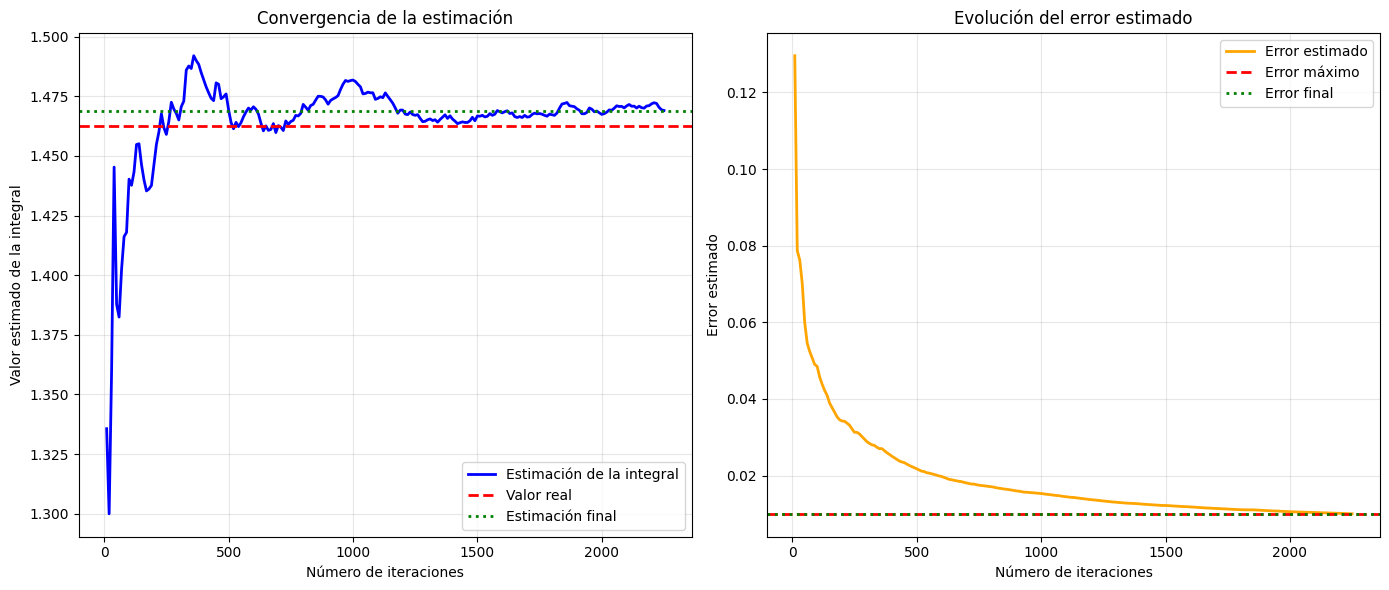

PRUEBA CON ERROR MÁS ESTRICTO (error_max = 0.001)
Error máximo: 0.001
Estimación de la integral: 1.463218065928762
Error estimado: 0.0009999985995467551
Iteraciones realizadas: 225280


In [ ]:
print("RESULTADO FINAL - Estimación de la integral")
print("Función: f(x) = e^(x²)")
print("Intervalo: [0, 1]")
print("Error máximo permitido: 0.01")
print("Iteraciones mínimas: 100")
print("Estimación de la integral:", resultado)
print("Error estimado:", error_final)
print("Iteraciones realizadas:", iteraciones)

valor_real = 1.4626517459071816
error_real = abs(resultado - valor_real)
print("Valor real aproximado:", valor_real)
print("Error respecto al valor real:", error_real)

n_vals, integral_vals, error_vals = zip(*historia)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(n_vals, integral_vals, 'b-', linewidth=2, label='Estimación de la integral')
plt.axhline(y=valor_real, color='r', linestyle='--', linewidth=2, label='Valor real')
plt.axhline(y=resultado, color='g', linestyle=':', linewidth=2, label='Estimación final')
plt.xlabel('Número de iteraciones')
plt.ylabel('Valor estimado de la integral')
plt.title('Convergencia de la estimación')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_vals, error_vals, 'orange', linewidth=2, label='Error estimado')
plt.axhline(y=error_max, color='r', linestyle='--', linewidth=2, label='Error máximo')
plt.axhline(y=error_final, color='g', linestyle=':', linewidth=2, label='Error final')
plt.xlabel('Número de iteraciones')
plt.ylabel('Error estimado')
plt.title('Evolución del error estimado')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PRUEBA CON ERROR MÁS ESTRICTO (error_max = 0.001)")


random.seed(42)

error_max_estricto = 0.001
resultado2, error_final2, iteraciones2, historia2 = integral_montecarlo(
    funcion_curva, a, b, error_max_estricto, min_iteraciones
)

print("Error máximo:", error_max_estricto)
print("Estimación de la integral:", resultado2)
print("Error estimado:", error_final2)
print("Iteraciones realizadas:", iteraciones2)

Muestra una línea que dibuja cómo se movía el valor estimado del área a lo largo de los intentos. Al principio la línea da saltos altos porque hay pocos datos, pero a medida que se suman más intentos, se estabiliza y se alinea.